# EDA

## Общая информация о датасете

In [1]:
from google.colab import files
import zipfile, os

# 1. Загрузить архив (появится диалог выбора файла)
uploaded = files.upload()   # выбери dataset_rework.zip

zip_name = list(uploaded.keys())[0]

# 2. Распаковать архив в текущую папку /content
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset_rework')

os.listdir('/content/dataset_rework')


Saving dataset_rework.zip to dataset_rework.zip


['2026-02-10-2',
 '2026-02-03',
 '2026-02-03-2',
 '2026-02-07',
 '2026-02-06-2',
 '2026-02-10',
 '2026-02-03-4',
 '2026-02-02',
 '2026-02-04',
 '__MACOSX',
 '2026-02-05-2',
 '2026-02-07-3',
 '2026-02-08-2',
 '2026-02-10-3',
 '2026-02-04-2',
 '2026-02-03-3',
 '2026-02-01-2',
 '2026-02-07-2',
 '2026-02-08-3',
 '2026-02-05',
 '2026-02-09',
 '2026-02-06',
 '2026-02-08']

In [5]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path("/content/dataset_rework")

rows = []

for f in ROOT_DIR.rglob("*.csv"):   # важно: *.csv
    folder = f.parent.name
    # пропускаем __MACOSX и любые папки, которые не начинаются с цифры
    if not folder[0].isdigit():
        continue

    # '2026-02-10-2' -> '2026-02-10'
    date_str = folder[:10]
    date = pd.to_datetime(date_str, format="%Y-%m-%d")

    try:
        tmp = pd.read_csv(f, encoding="utf-8")   # если упадёт — сменим кодировку
    except UnicodeDecodeError:
        tmp = pd.read_csv(f, encoding="cp1251")

    tmp["date"] = date
    tmp["ticker"] = f.stem
    rows.append(tmp)

print("Сколько файлов прочитано:", len(rows))

df = pd.concat(rows, ignore_index=True)
print(df[["date", "ticker"]].head())


Сколько файлов прочитано: 1666
        date   ticker
0 2026-02-10  CLANKER
1 2026-02-10  CLANKER
2 2026-02-10  CLANKER
3 2026-02-10  CLANKER
4 2026-02-10  CLANKER


In [6]:
df

,timestamp;symbol;rd_value;open;high;low;close;volume;signal_barrier,date,ticker,timestamp,symbol,rd_value,open,high,low,close,volume,signal_barrier,Unnamed: 0
0,1770703560000;CLANKER;-0.05649974;33.403;33.40...,2026-02-10,CLANKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1770703620000;CLANKER;-0.23050846;33.209;33.20...,2026-02-10,CLANKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1770703680000;CLANKER;-0.37676623;32.87;32.964...,2026-02-10,CLANKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1770703740000;CLANKER;-0.602528;32.723;32.732;...,2026-02-10,CLANKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1770703800000;CLANKER;-0.9542322;32.268;32.392...,2026-02-10,CLANKER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395648,NaN,2026-02-08,WCT,1.770547e+12,WCT,-1.963068,0.05723,0.05726,0.05719,0.05724,18826.0,1.0,NaN
395649,NaN,2026-02-08,WCT,1.770547e+12,WCT,-1.979255,0.05724,0.05724,0.05716,0.05716,6109.0,-1.0,NaN
395650,NaN,2026-02-08,WCT,1.770547e+12,WCT,-1.976433,0.05717,0.05724,0.05717,0.05724,1032.0,1.0,NaN
395651,NaN,2026-02-08,WCT,1.770548e+12,WCT,-1.998167,0.05724,0.05724,0.05711,0.05713,11210.0,-1.0,NaN


In [10]:
import numpy as np
import pandas as pd

# 1. Общая информация
print("Shape (строки, колонки)")
print(df.shape)

print("\nТипы переменных")
print(df.dtypes)

# 2. Преобразование timestamp в datetime (если ещё не сделали)
if "datetime" not in df.columns:
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

print("\nДиапазон дат и времени")
print(df["datetime"].min(), "->", df["datetime"].max())

# 3. Проверка равномерности временного шага по каждому символу
print("\nTop 5 встречающихся шагов по времени")
for sym, g in df.groupby("symbol"):
    g_sorted = g.sort_values("datetime")
    deltas = g_sorted["datetime"].diff().dropna()
    print(f"\nТикер: {sym}")
    print(deltas.value_counts().head(5))

# 4. Пропуски и дубликаты
print("\nПропущенные значения в каждом столбце")
print(df.isna().sum())

print("\nКоличество повторяющихся строк")
print(df.duplicated().sum())

# 5. Базовая описательная статистика

# числовые колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nОписания числовые столбцы")
print(df[numeric_cols].describe())

# категориальные колонки: symbol, ticker (и при желании date как категорию)
print("\nИмеют значение: symbol (топ-10)")
print(df["symbol"].value_counts().head(10))

print("\nИмеют значение: ticker (топ-10)")
print(df["ticker"].value_counts().head(10))

print("\nЦенность имеет: signal_barrier")
print(df["signal_barrier"].value_counts(dropna=False))

# 6. Выбросы по цене и объёму (через IQR)
def iqr_outliers(series: pd.Series, name: str):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    print(f"\nВыбросы для {name}")
    print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
    print(f"Нижняя граница: {lower}, Верхняя граница: {upper}")
    print(f"Количество выбросов: {mask.sum()} / {series.notna().sum()}")

# замечание: в новом датасете колонка называется 'close', а не 'close_price'
iqr_outliers(df["close"], "close")
iqr_outliers(df["volume"], "volume")


Shape (строки, колонки)
(395653, 14)

Типы переменных
timestamp;symbol;rd_value;open;high;low;close;volume;signal_barrier            object
date                                                                   datetime64[ns]
ticker                                                                         object
timestamp                                                                     float64
symbol                                                                         object
rd_value                                                                      float64
open                                                                          float64
high                                                                          float64
low                                                                           float64
close                                                                         float64
volume                                                                        float64


In [11]:
# вывожу уникальные тикеры для построения графиков цены их закрытия
print(df["symbol"].unique())

def plot_symbol(sym):
    sub = df[df["symbol"] == sym].sort_values("timestamp").copy()
    sub["datetime"] = pd.to_datetime(sub["timestamp"], unit="ms")

    plt.figure(figsize=(12,5))
    plt.plot(sub["datetime"], sub["close_price"])
    plt.title(sym)
    plt.grid(alpha=0.3)
    plt.show()

[nan 'SIREN' 'CLANKER' 'NS' 'LA' 'AIO' 'F' 'AWE' 'WHITEWHALE' 'KGEN'
 'TRIA' '1000X' 'XNY' 'PTB' 'JCT' 'ORBS' 'BREV' 'ACU' 'NAORIS' 'OL' 'ARC'
 'DUSK' 'PIPPIN' 'KITE' 'BIRB' 'SNT' 'ZIL' 'BANANAS31' 'IRYS' 'BEAT' 'OG'
 'FOLKS' 'CUDIS' 'LIGHT' 'AVAAI' 'ZK' 'RIVER' 'ZKP' 'ZORA' 'CVC' 'FIGHT'
 'INX' 'UAI' 'CYS' 'ENSO' 'HANA' 'BOBBOB' 'MANTA' 'FLOW' 'B2' 'STABLE'
 '1000TAG' 'HIVE' 'US' 'IN' 'CLO' 'CARV' 'ROAM' 'BERA' 'JELLYJELLY' 'AIN'
 'SKR' 'ARK' 'BOBA' '1000RATS' 'H' 'STORJ' 'API3' 'SKYAI' 'FHE' 'ZRO'
 'ROSE' 'S' 'PYR' 'APEX' 'POWER' 'FLUX' 'COW' 'ALCH' 'TRUTH' 'HEMI' 'ZBCN'
 'SAROS' 'SPORTFUN' 'THE' 'LSK' 'CLOUD' 'PONKE' 'VELVET' 'RESOLV' 'M'
 'PEAQ' 'MAGIC' 'GIGA' 'GPS' 'WCT']


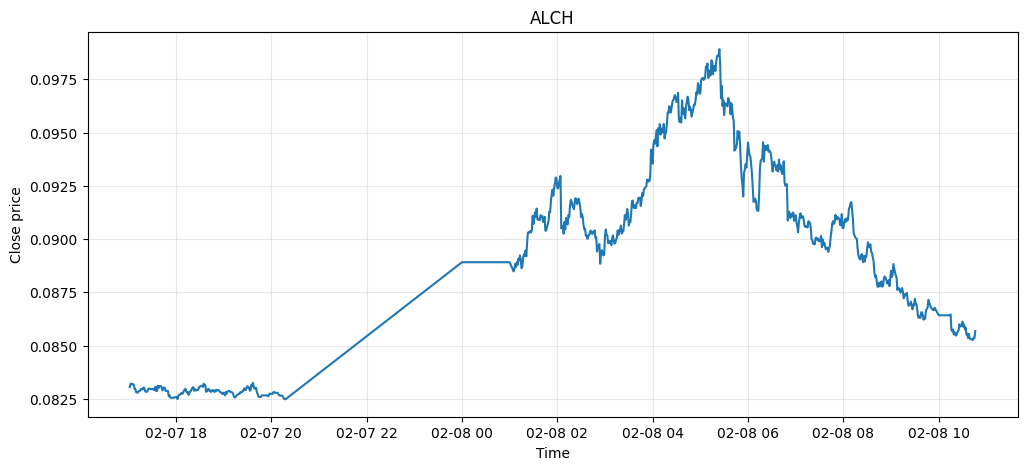

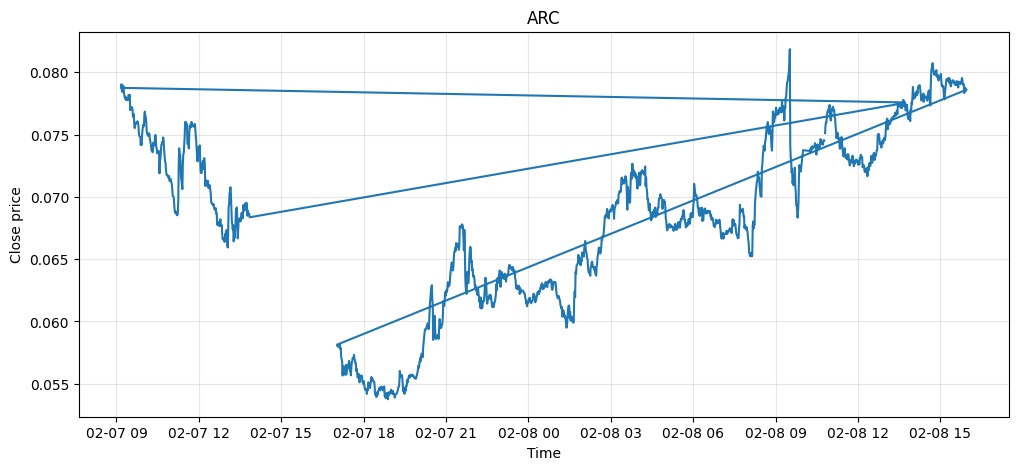

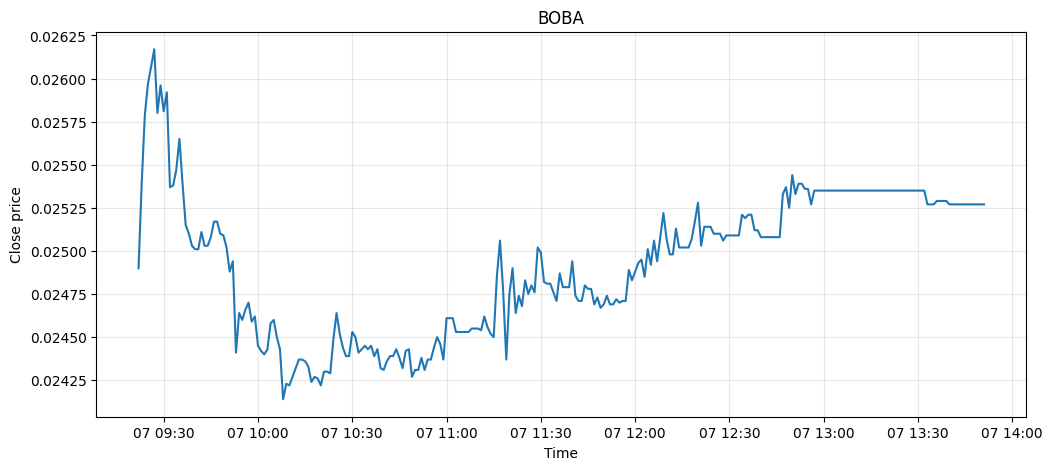

Тикер COMMON: данных нет


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_symbol(sym):
    sub = df[df["symbol"] == sym].copy()
    if sub.empty:
        print(f"Тикер {sym}: данных нет")
        return

    # datetime уже есть, но на всякий случай
    if "datetime" not in sub.columns:
        sub["datetime"] = pd.to_datetime(sub["timestamp"], unit="ms")

    plt.figure(figsize=(12, 5))
    plt.plot(sub["datetime"], sub["close"])   # используем колонку close
    plt.title(sym)
    plt.xlabel("Time")
    plt.ylabel("Close price")
    plt.grid(alpha=0.3)
    plt.show()

# заново вызываем
plot_symbol("ALCH")
plot_symbol("ARC")
plot_symbol("BOBA")
plot_symbol("COMMON")


Тикер ARIA: данных нет


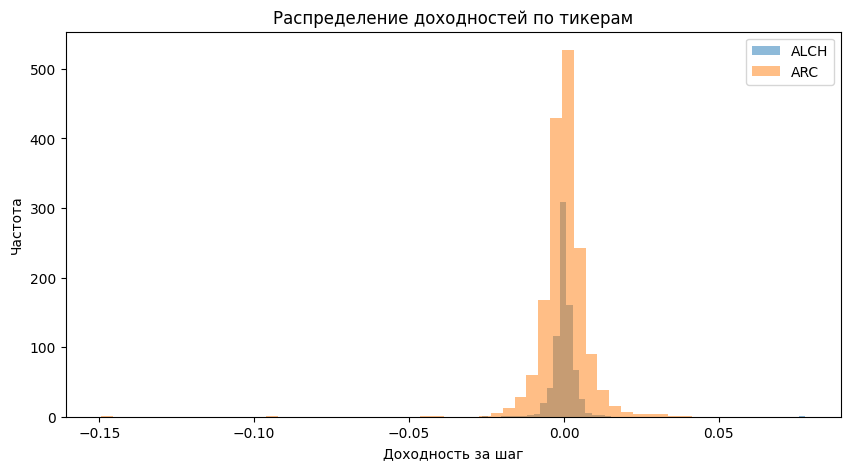

In [16]:
plt.figure(figsize=(10, 5))

for sym in ['ALCH', 'ARC', 'ARIA']:
    sub = df[df["symbol"] == sym].sort_values("timestamp").copy()
    if sub.empty:
        print(f"Тикер {sym}: данных нет")
        continue

    sub["ret"] = sub["close"].pct_change()
    plt.hist(sub["ret"].dropna(), bins=50, alpha=0.5, label=sym)

plt.legend()
plt.xlabel("Доходность за шаг")
plt.ylabel("Частота")
plt.title("Распределение доходностей по тикерам")
plt.show()


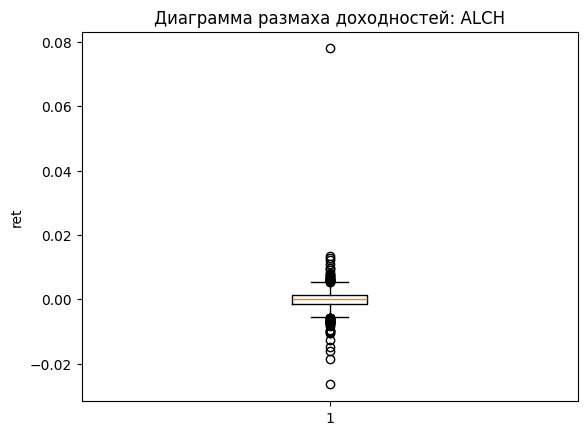

In [18]:
import matplotlib.pyplot as plt

sym = "ALCH"  # можно подставлять любой из перечисленных

sub = df[df["symbol"] == sym].sort_values("timestamp").copy()

if sub.empty:
    print(f"Тикер {sym}: данных нет")
else:
    sub["ret"] = sub["close"].pct_change()

    plt.figure()
    plt.boxplot(sub["ret"].dropna())
    plt.title(f"Диаграмма размаха доходностей: {sym}")
    plt.ylabel("ret")
    plt.show()


## Оценка сигнала

In [21]:
# убеждаемся, что колонка datetime есть
if "datetime" not in df.columns:
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

sig = df[["datetime", "symbol", "signal_barrier"]].copy()

# Баланс классов (BUY/SELL/HOLD) и дисбаланс
print("Баланс классов для signal_barrier")
print(sig["signal_barrier"].value_counts(dropna=False))

print("\nСоотношения классов для signal_barrier")
print(sig["signal_barrier"].value_counts(normalize=True, dropna=False))

print("\nБаланс классов по символам")
print(
    sig.pivot_table(
        index="symbol",
        columns="signal_barrier",
        values="datetime",
        aggfunc="count"
    ).fillna(0).head()
)

# Динамика сигналов во времени (по дням и по часам)
non_null = sig.dropna(subset=["signal_barrier"]).copy()
non_null["date"] = non_null["datetime"].dt.date
non_null["hour"] = non_null["datetime"].dt.hour

print("\nКоличество сигналов в день (первые 10 дней)")
signals_by_day = (
    non_null
    .groupby(["date", "signal_barrier"])
    .size()
    .unstack(fill_value=0)
    .head(10)
)
print(signals_by_day)

print("\nСигналы каждый час дня")
signals_by_hour = (
    non_null
    .groupby(["hour", "signal_barrier"])
    .size()
    .unstack(fill_value=0)
)
print(signals_by_hour)

# Длина последовательностей одинаковых сигналов
non_null_sorted = non_null.sort_values(["symbol", "datetime"])

non_null_sorted["signal_changed"] = (
    non_null_sorted.groupby("symbol")["signal_barrier"]
    .apply(lambda s: s.ne(s.shift()).astype(int))
    .reset_index(level=0, drop=True)
)

non_null_sorted["run_id"] = non_null_sorted.groupby("symbol")["signal_changed"].cumsum()

run_lengths = (
    non_null_sorted
    .groupby(["symbol", "run_id", "signal_barrier"])
    .size()
    .reset_index(name="run_length")
)

print("\nДлина последовательности")
print(run_lengths.head(20))

print("\nСтатистика длительности серий для каждого сигнала")
run_stats = run_lengths.groupby("signal_barrier")["run_length"].describe()
print(run_stats)

# Серийность сигналов и частота смены сигналов
freq_list = []

for sym, g in non_null_sorted.groupby("symbol"):
    g_sorted = g.sort_values("datetime")
    n_changes = (g_sorted["signal_barrier"] != g_sorted["signal_barrier"].shift()).sum()

    if len(g_sorted) > 1:
        hours_span = (g_sorted["datetime"].max() - g_sorted["datetime"].min()).total_seconds() / 3600.0
    else:
        hours_span = np.nan

    changes_per_hour = n_changes / hours_span if hours_span and hours_span > 0 else np.nan

    freq_list.append({
        "symbol": sym,
        "n_points": len(g_sorted),
        "n_changes": int(n_changes),
        "hours_span": hours_span,
        "changes_per_hour": changes_per_hour,
    })

signal_change_freq = pd.DataFrame(freq_list)

print("\nЧастота изменения сигнала на символ")
print(signal_change_freq.head(20))

# Общая серийность по всем символам
total_changes = (non_null_sorted["signal_barrier"] != non_null_sorted["signal_barrier"].shift()).sum()
total_hours = (non_null_sorted["datetime"].max() - non_null_sorted["datetime"].min()).total_seconds() / 3600.0

print("\nГлобальная частота изменения сигнала")
print(f"Общие изменения: {total_changes}, общее количество часов: {total_hours}, "
      f"изменения/час: {total_changes / total_hours:.4f}")



Баланс классов для signal_barrier
signal_barrier
 NaN    330727
 1.0     32729
-1.0     32197
Name: count, dtype: int64

Соотношения классов для signal_barrier
signal_barrier
 NaN    0.835902
 1.0    0.082721
-1.0    0.081377
Name: proportion, dtype: float64

Баланс классов по символам
signal_barrier  -1.0   1.0
symbol                    
1000RATS         141   143
1000TAG          563   772
1000X             98   101
ACU              731   778
AIN              139   145

Количество сигналов в день (первые 10 дней)
signal_barrier   -1.0    1.0
date                        
2026-02-01       2264   2273
2026-02-07      12424  12709
2026-02-08      17509  17747

Сигналы каждый час дня
signal_barrier  -1.0   1.0
hour                      
0               1365  1221
1               1264  1408
2               1352  1240
3               1263  1315
4               1229  1308
5               1201  1330
6               1369  1262
7               1344  1309
8               1271  1395
9            

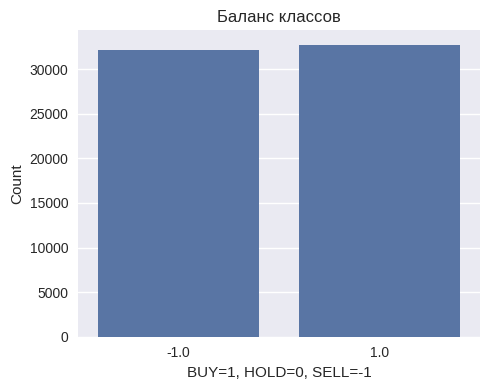

<Figure size 1000x400 with 0 Axes>

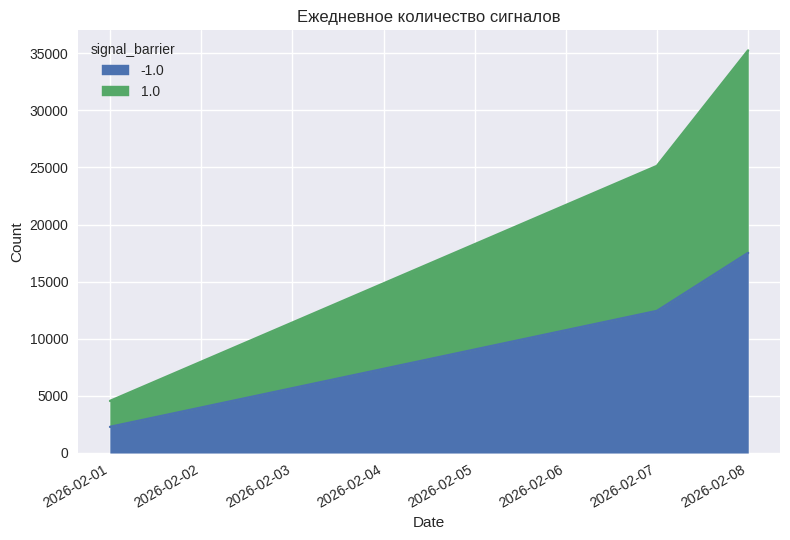

<Figure size 800x400 with 0 Axes>

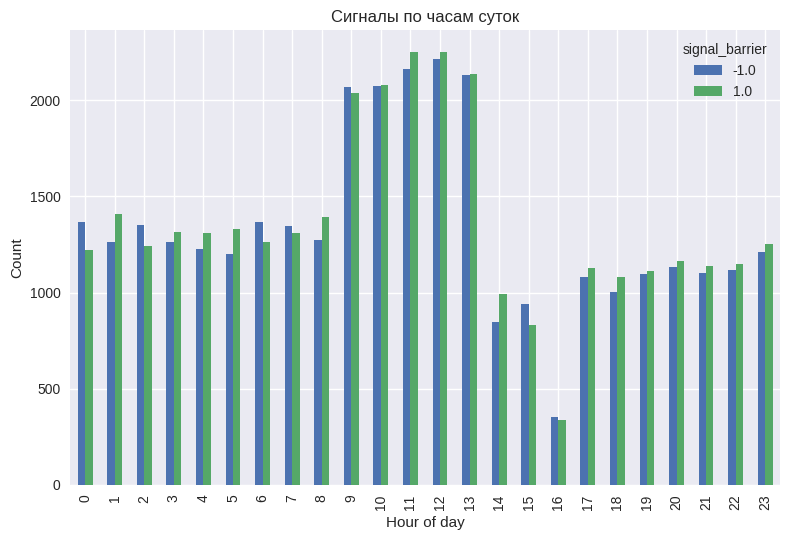

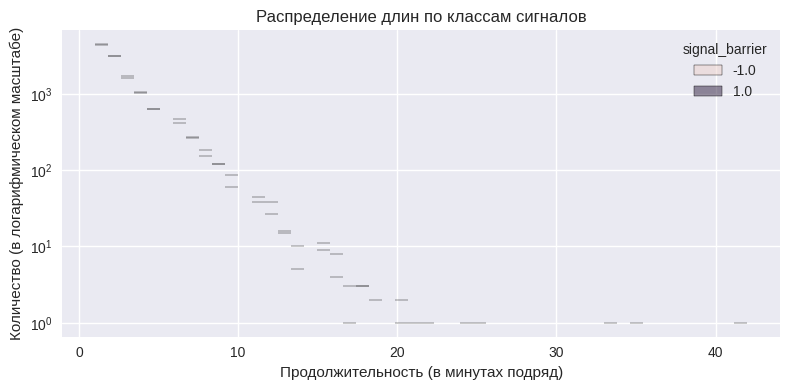

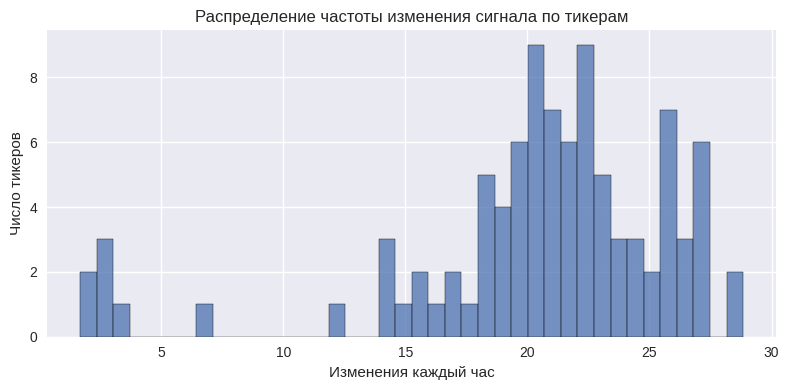

In [22]:
import seaborn as sns

plt.style.use("seaborn-v0_8")

df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

sig = df[["datetime", "symbol", "signal_barrier"]].copy()
non_null = sig.dropna(subset=["signal_barrier"]).copy()
non_null["date"] = non_null["datetime"].dt.date
non_null["hour"] = non_null["datetime"].dt.hour

# Баланс классов

plt.figure(figsize=(5, 4))
sns.countplot(
    data=non_null,
    x="signal_barrier",
    order=sorted(non_null["signal_barrier"].unique())
)
plt.title("Баланс классов")
plt.xlabel("BUY=1, HOLD=0, SELL=-1")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Динамика сигналов во времени (по дням и по часам)

# По дням
by_day = (
    non_null
    .groupby(["date", "signal_barrier"])
    .size()
    .unstack(fill_value=0)
)
by_day.index = pd.to_datetime(by_day.index)

plt.figure(figsize=(10, 4))
by_day.sort_index().plot(kind="area", stacked=True)
plt.title("Ежедневное количество сигналов")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# По часам суток
by_hour = (
    non_null
    .groupby(["hour", "signal_barrier"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(8, 4))
by_hour.plot(kind="bar")
plt.title("Сигналы по часам суток")
plt.xlabel("Hour of day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Длина последовательностей одинаковых сигналов

non_null_sorted = non_null.sort_values(["symbol", "datetime"])

non_null_sorted["signal_changed"] = (
    non_null_sorted
    .groupby("symbol")["signal_barrier"]
    .apply(lambda s: s.ne(s.shift()).astype(int))
    .reset_index(level=0, drop=True)
)

# run_id - идентификатор последовательности одинаковых сигналов
non_null_sorted["run_id"] = (
    non_null_sorted
    .groupby("symbol")["signal_changed"]
    .cumsum()
)

run_lengths = (
    non_null_sorted
    .groupby(["symbol", "run_id", "signal_barrier"])
    .size()
    .reset_index(name="run_length")
)

plt.figure(figsize=(8, 4))
sns.histplot(
    data=run_lengths,
    x="run_length",
    hue="signal_barrier",
    bins=50,
    log_scale=(False, True)
)
plt.title("Распределение длин по классам сигналов")
plt.xlabel("Продолжительность (в минутах подряд)")
plt.ylabel("Количество (в логарифмическом масштабе)")
plt.tight_layout()
plt.show()

# Серийность и частота смены сигналов

freq_list = []
for sym, g in non_null_sorted.groupby("symbol"):
    g_sorted = g.sort_values("datetime")
    n_changes = (g_sorted["signal_barrier"] != g_sorted["signal_barrier"].shift()).sum()
    if len(g_sorted) > 1:
        hours_span = (
            g_sorted["datetime"].max() - g_sorted["datetime"].min()
        ).total_seconds() / 3600.0
    else:
        hours_span = np.nan
    changes_per_hour = n_changes / hours_span if hours_span and hours_span > 0 else np.nan

    freq_list.append({
        "symbol": sym,
        "changes_per_hour": changes_per_hour,
    })  # [file:1]

freq_df = pd.DataFrame(freq_list).dropna()  # [file:1]

plt.figure(figsize=(8, 4))
sns.histplot(freq_df["changes_per_hour"], bins=40)
plt.title("Распределение частоты изменения сигнала по тикерам")
plt.xlabel("Изменения каждый час")
plt.ylabel("Число тикеров")
plt.tight_layout()
plt.show()


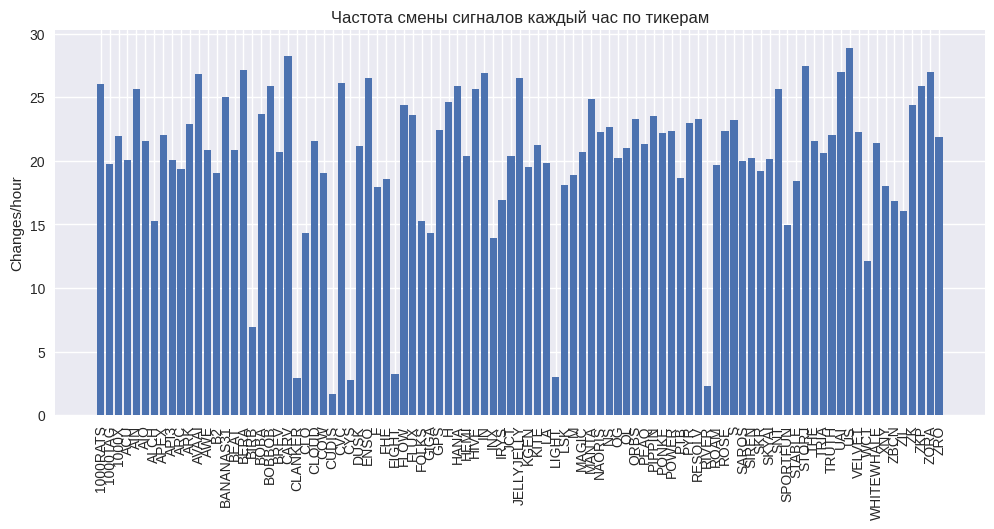

In [23]:
plt.figure(figsize=(12,5))

plt.bar(
    signal_change_freq["symbol"],
    signal_change_freq["changes_per_hour"]
)

plt.xticks(rotation=90)
plt.title("Частота смены сигналов каждый час по тикерам")
plt.ylabel("Changes/hour")
plt.show()

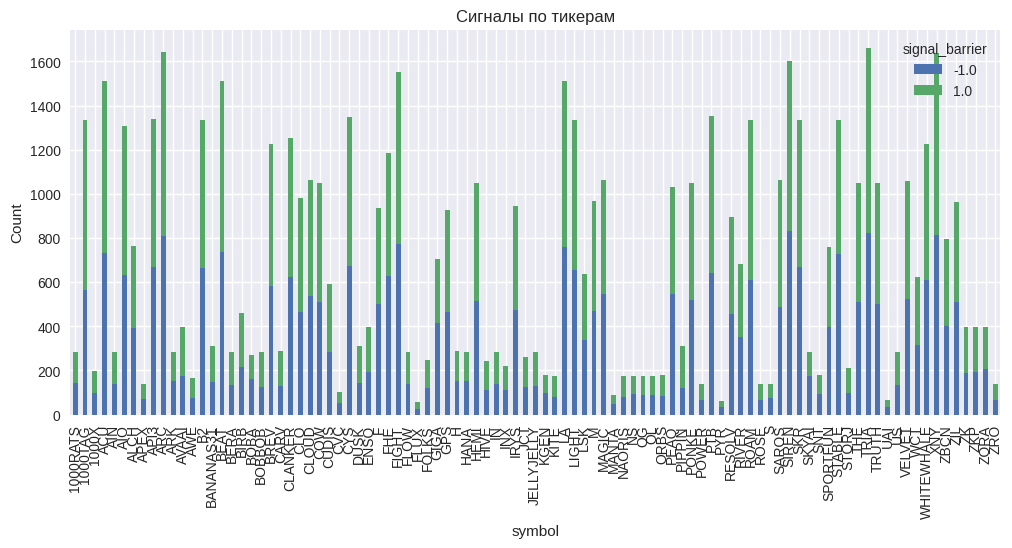

In [24]:
pivot = sig.pivot_table(
    index="symbol",
    columns="signal_barrier",
    values="datetime",
    aggfunc="count"
).fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(12,5))
plt.title("Сигналы по тикерам")
plt.ylabel("Count")
plt.show()

## Оценка цены

Пример сравнения цены закрытия и времени для символа, достигшего вершины списка
TRIA
                  datetime     close
227800 2026-02-07 09:06:00  0.020402
227801 2026-02-07 09:07:00  0.020360
227802 2026-02-07 09:08:00  0.020185
227803 2026-02-07 09:09:00  0.020165
227804 2026-02-07 09:10:00  0.020224
227805 2026-02-07 09:11:00  0.020265
227806 2026-02-07 09:12:00  0.020165
227807 2026-02-07 09:13:00  0.020213
227808 2026-02-07 09:14:00  0.020211
227809 2026-02-07 09:15:00  0.020324
227810 2026-02-07 09:16:00  0.020379
227811 2026-02-07 09:17:00  0.020382
227812 2026-02-07 09:18:00  0.020470
227813 2026-02-07 09:19:00  0.020577
227814 2026-02-07 09:20:00  0.020456
227815 2026-02-07 09:21:00  0.020609
227816 2026-02-07 09:22:00  0.020562
227817 2026-02-07 09:23:00  0.020706
227818 2026-02-07 09:24:00  0.020707
227819 2026-02-07 09:25:00  0.020767

Пересэмплированная цена закрытия (1 минута)
datetime
2026-02-07 09:06:00    0.020402
2026-02-07 09:07:00    0.020360
2026-02-07 09:08:00 

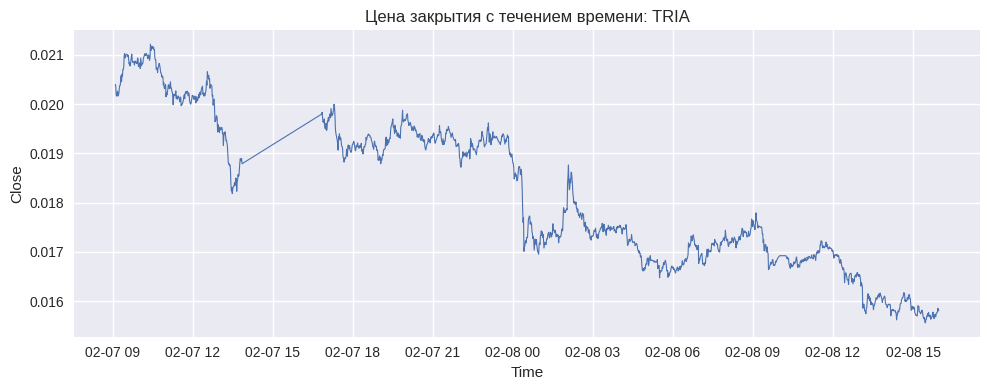

In [27]:
top_symbol = df["symbol"].value_counts().idxmax()
df_sym = df[df["symbol"] == top_symbol].copy()
df_sym = df_sym.sort_values("datetime")

print("Пример сравнения цены закрытия и времени для символа, достигшего вершины списка")
print(top_symbol)
print(df_sym[["datetime", "close"]].head(20))

# если в одной минуте несколько записей — берём последнюю цену
sym_minute = (
    df_sym
    .set_index("datetime")["close"]
    .resample("1min")      # вместо '1T'
    .last()                # можно .mean(), .first() и т.п.
)

# на всякий случай удалим возможные оставшиеся NaN
df_sym_ts = sym_minute.ffill()

print("\nПересэмплированная цена закрытия (1 минута)")
print(df_sym_ts.head(20))

# Базовая статистика по цене во времени (по дням)
print("\nСтатистика закрытия за день")
daily_price_stats = (
    df_sym
    .set_index("datetime")["close"]
    .resample("1D")
    .agg(["min", "max", "mean"])
)
print(daily_price_stats.head(10))

# График цены top_symbol
plt.figure(figsize=(10, 4))
plt.plot(df_sym["datetime"], df_sym["close"], linewidth=0.8)
plt.title(f"Цена закрытия с течением времени: {top_symbol}")
plt.xlabel("Time")
plt.ylabel("Close")
plt.tight_layout()
plt.show()


## Связь с сигналами

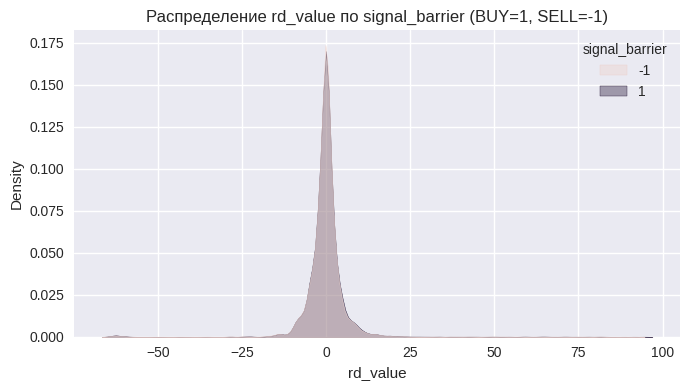

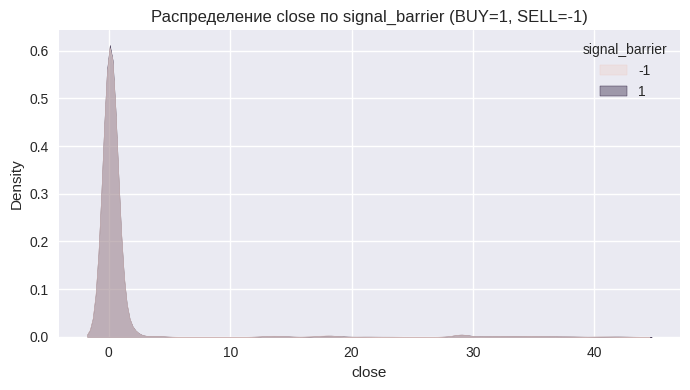

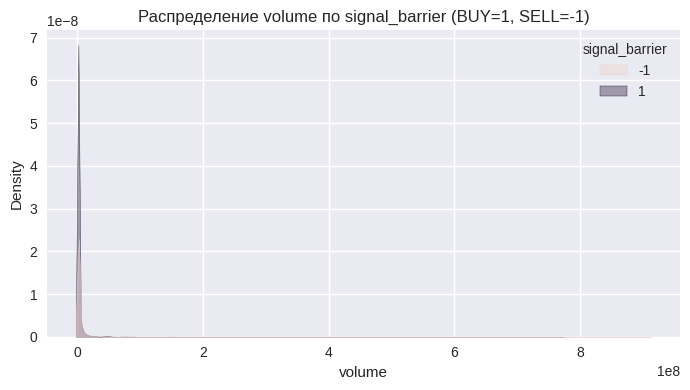

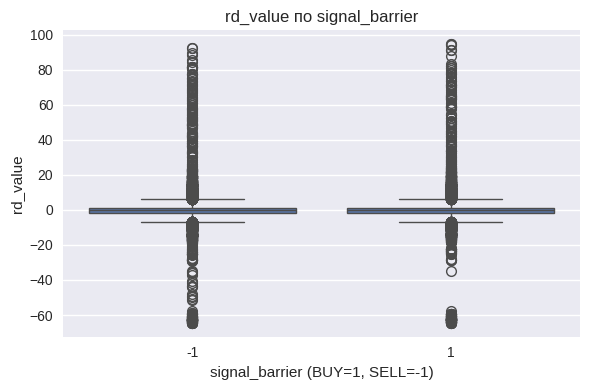

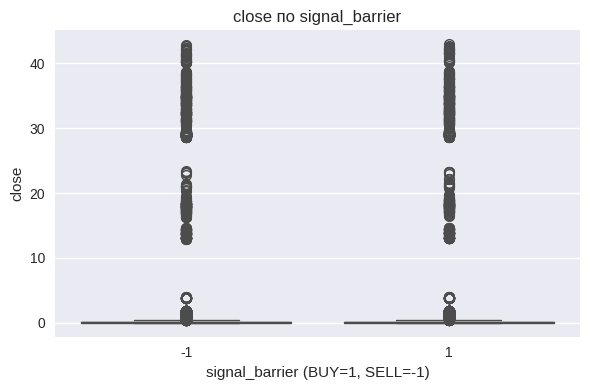

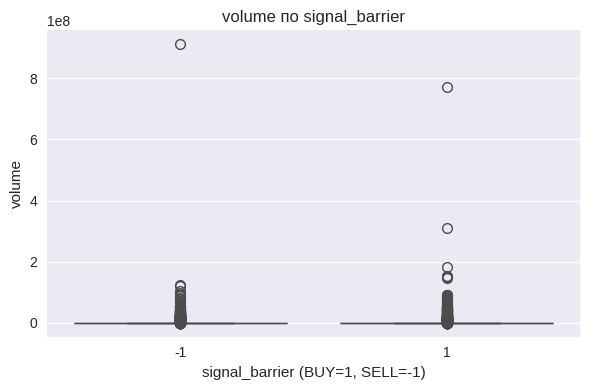

Корреляционная матрица
          rd_value     close    volume
rd_value  1.000000  0.016769  0.048084
close     0.016769  1.000000 -0.019268
volume    0.048084 -0.019268  1.000000


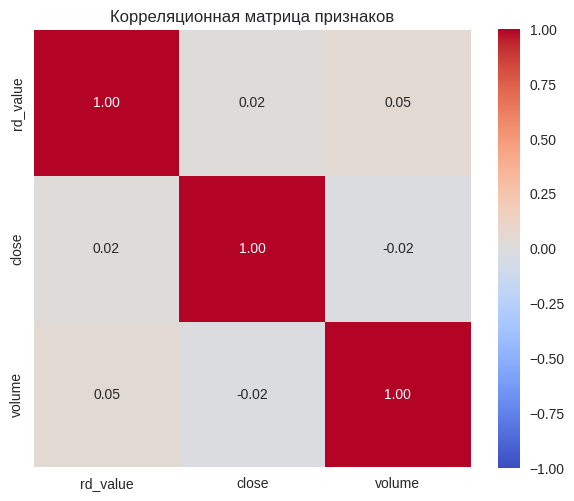


Корреляция признаков с уровнем signal_barrier
signal_barrier    1.000000
rd_value          0.003886
volume            0.000272
close            -0.001177
Name: signal_barrier, dtype: float64


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# берём только строки, где есть сигнал
df_sig = df.dropna(subset=["signal_barrier"]).copy()
df_sig["signal_barrier"] = df_sig["signal_barrier"].astype(int)

# признаки, которые реально есть
feature_cols = ["rd_value", "close", "volume"]

# Распределения признаков по классам сигналов (BUY/SELL)
for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(
        data=df_sig,
        x=col,
        hue="signal_barrier",
        common_norm=False,
        fill=True,
        alpha=0.4
    )
    plt.title(f"Распределение {col} по signal_barrier (BUY=1, SELL=-1)")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

# boxplot по классам сигналов
for col in feature_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df_sig,
        x="signal_barrier",
        y=col
    )
    plt.title(f"{col} по signal_barrier")
    plt.xlabel("signal_barrier (BUY=1, SELL=-1)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Корреляционная матрица
numeric_cols = feature_cols

corr = df_sig[numeric_cols].corr(method="pearson")
print("Корреляционная матрица")
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

# Корреляция признаков с таргетом
corr_with_target = df_sig[feature_cols + ["signal_barrier"]].corr()["signal_barrier"].sort_values(ascending=False)
print("\nКорреляция признаков с уровнем signal_barrier")
print(corr_with_target)



## Влияние времени суток и времени на сигналы

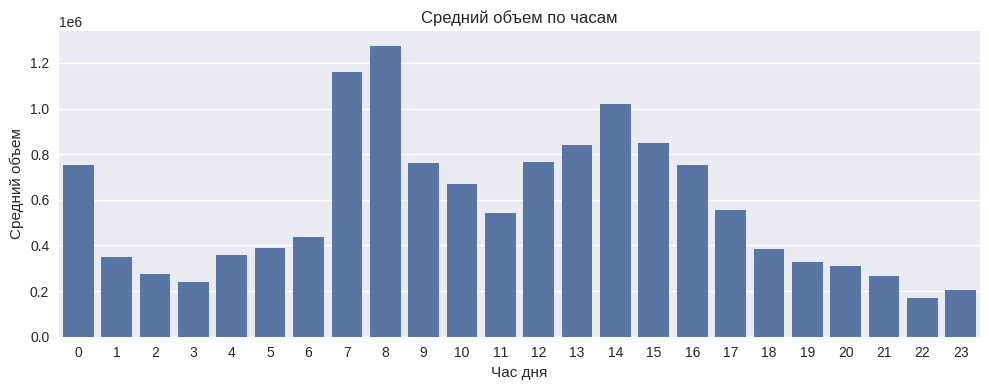

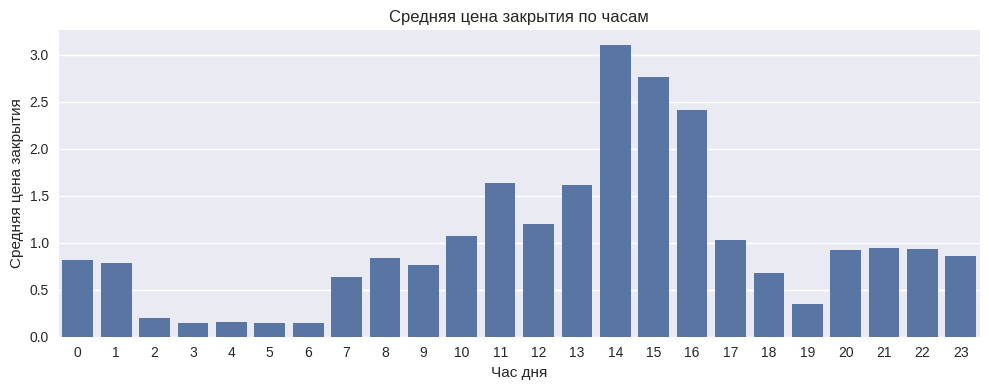

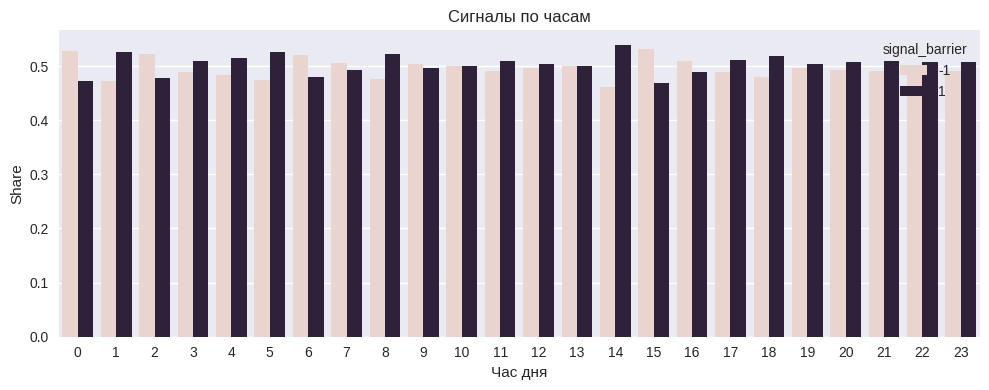

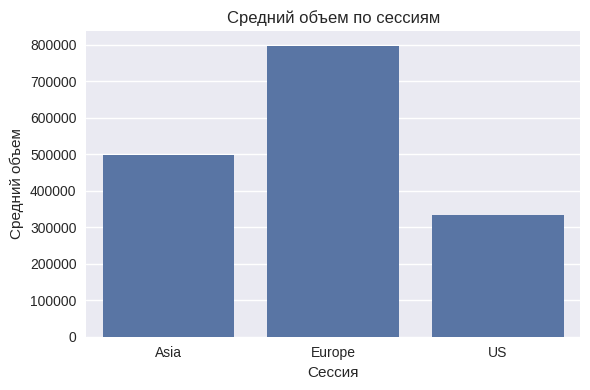

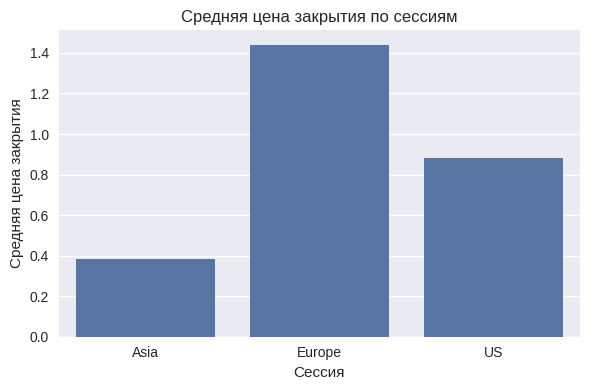

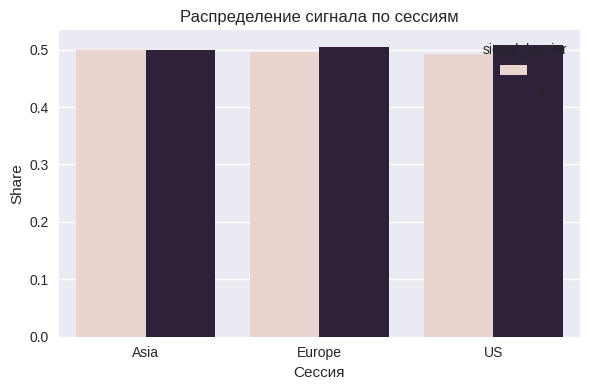

In [35]:
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
df_sig = df.dropna(subset=["signal_barrier"]).copy()
df_sig["signal_barrier"] = df_sig["signal_barrier"].astype(int)
df_sig["hour"] = df_sig["datetime"].dt.hour

def session_from_hour(h):
    if 0 <= h <= 7:
        return "Asia"
    elif 8 <= h <= 15:
        return "Europe"
    else:
        return "US"

df_sig["session"] = df_sig["hour"].apply(session_from_hour)

# Средний объём и цена по часам
hourly_stats = (
    df_sig.groupby("hour")[["close", "volume"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=hourly_stats, x="hour", y="volume")
plt.title("Средний объем по часам")
plt.xlabel("Час дня")
plt.ylabel("Средний объем")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=hourly_stats, x="hour", y="close")
plt.title("Средняя цена закрытия по часам")
plt.xlabel("Час дня")
plt.ylabel("Средняя цена закрытия")
plt.tight_layout()
plt.show()

# Доли BUY/SELL по часам
sig_by_hour = (
    df_sig
    .groupby(["hour", "signal_barrier"])
    .size()
    .reset_index(name="count")
)

sig_by_hour["share"] = (
    sig_by_hour.groupby("hour")["count"]
    .transform(lambda x: x / x.sum())
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=sig_by_hour,
    x="hour",
    y="share",
    hue="signal_barrier"
)
plt.title("Сигналы по часам")
plt.xlabel("Час дня")
plt.ylabel("Share")
plt.legend(title="signal_barrier")
plt.tight_layout()
plt.show()

# Средний объём и цена по сессиям
session_stats = (
    df_sig.groupby("session")[["close", "volume"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=session_stats, x="session", y="volume")
plt.title("Средний объем по сессиям")
plt.xlabel("Сессия")
plt.ylabel("Средний объем")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=session_stats, x="session", y="close")
plt.title("Средняя цена закрытия по сессиям")
plt.xlabel("Сессия")
plt.ylabel("Средняя цена закрытия")
plt.tight_layout()
plt.show()

# Доли BUY/SELL по сессиям
sig_by_session = (
    df_sig
    .groupby(["session", "signal_barrier"])
    .size()
    .reset_index(name="count")
)

sig_by_session["share"] = (
    sig_by_session.groupby("session")["count"]
    .transform(lambda x: x / x.sum())
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=sig_by_session,
    x="session",
    y="share",
    hue="signal_barrier"
)
plt.title("Распределение сигнала по сессиям")
plt.xlabel("Сессия")
plt.ylabel("Share")
plt.legend(title="signal_barrier")
plt.tight_layout()
plt.show()



<Figure size 1000x400 with 0 Axes>

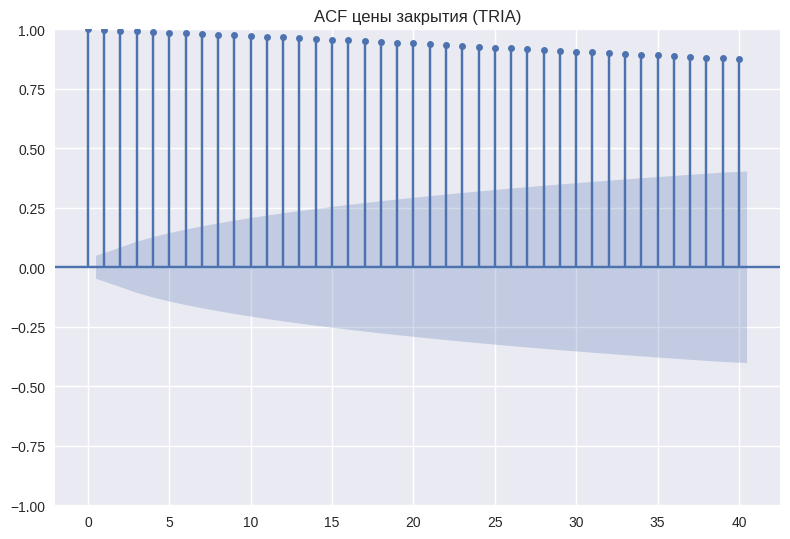

<Figure size 1000x400 with 0 Axes>

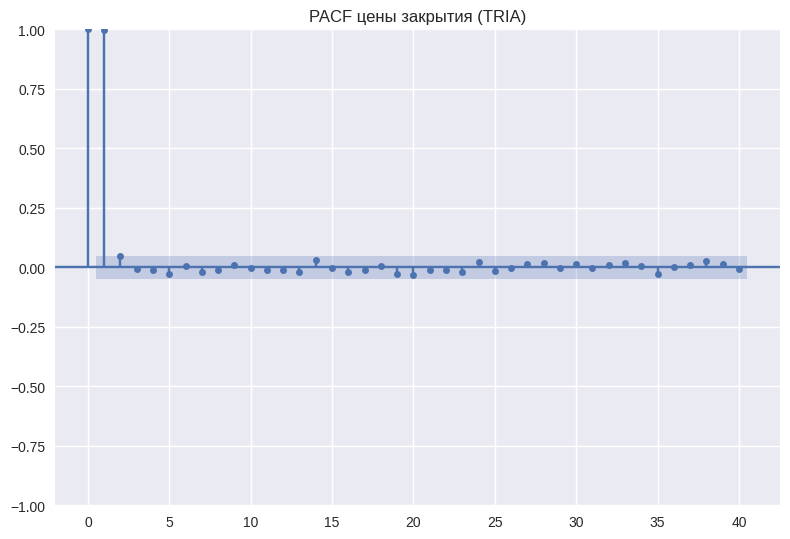

<Figure size 1000x400 with 0 Axes>

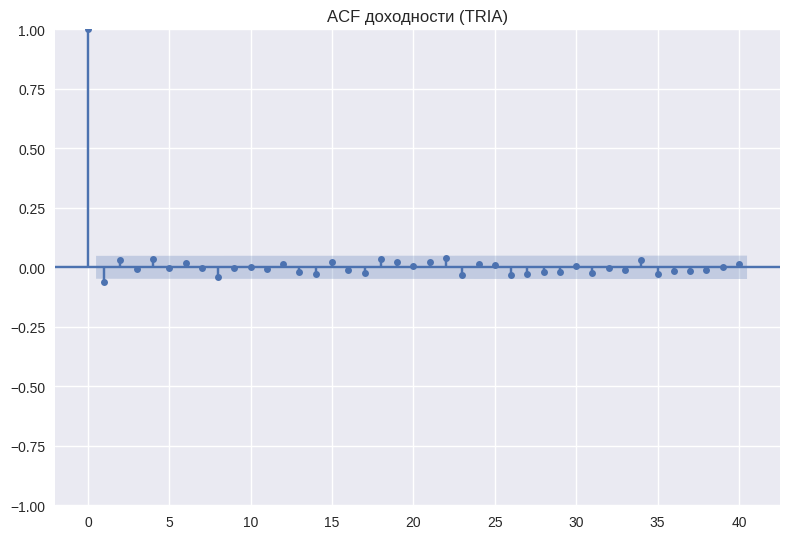

<Figure size 1000x400 with 0 Axes>

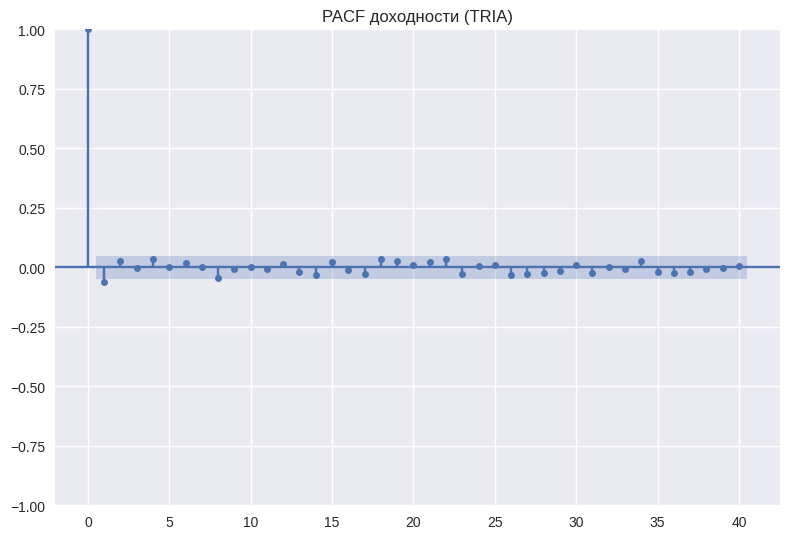

<Figure size 1000x400 with 0 Axes>

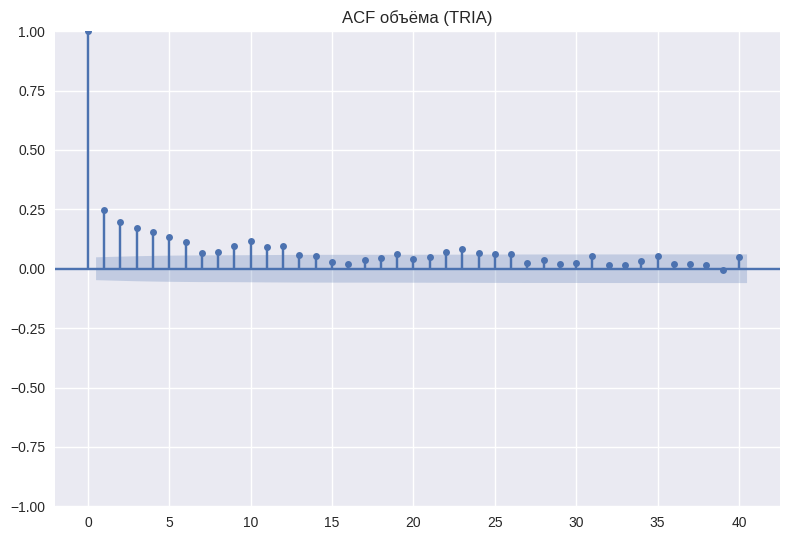

<Figure size 1000x400 with 0 Axes>

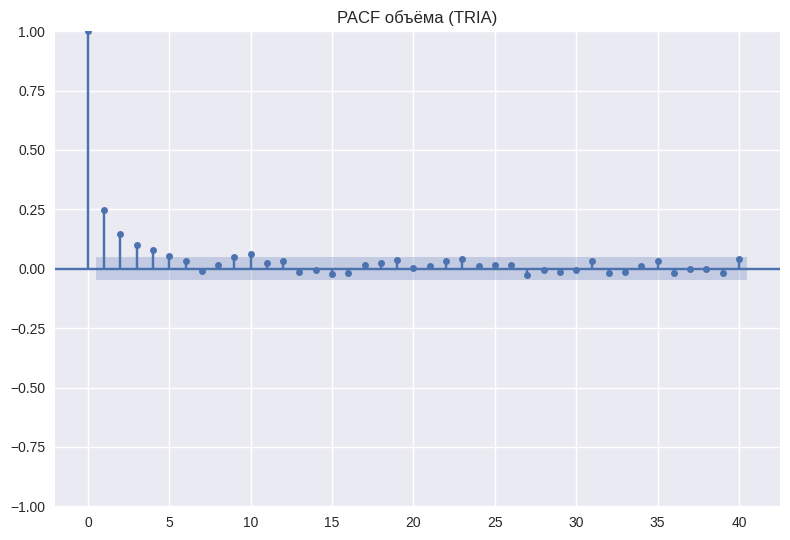

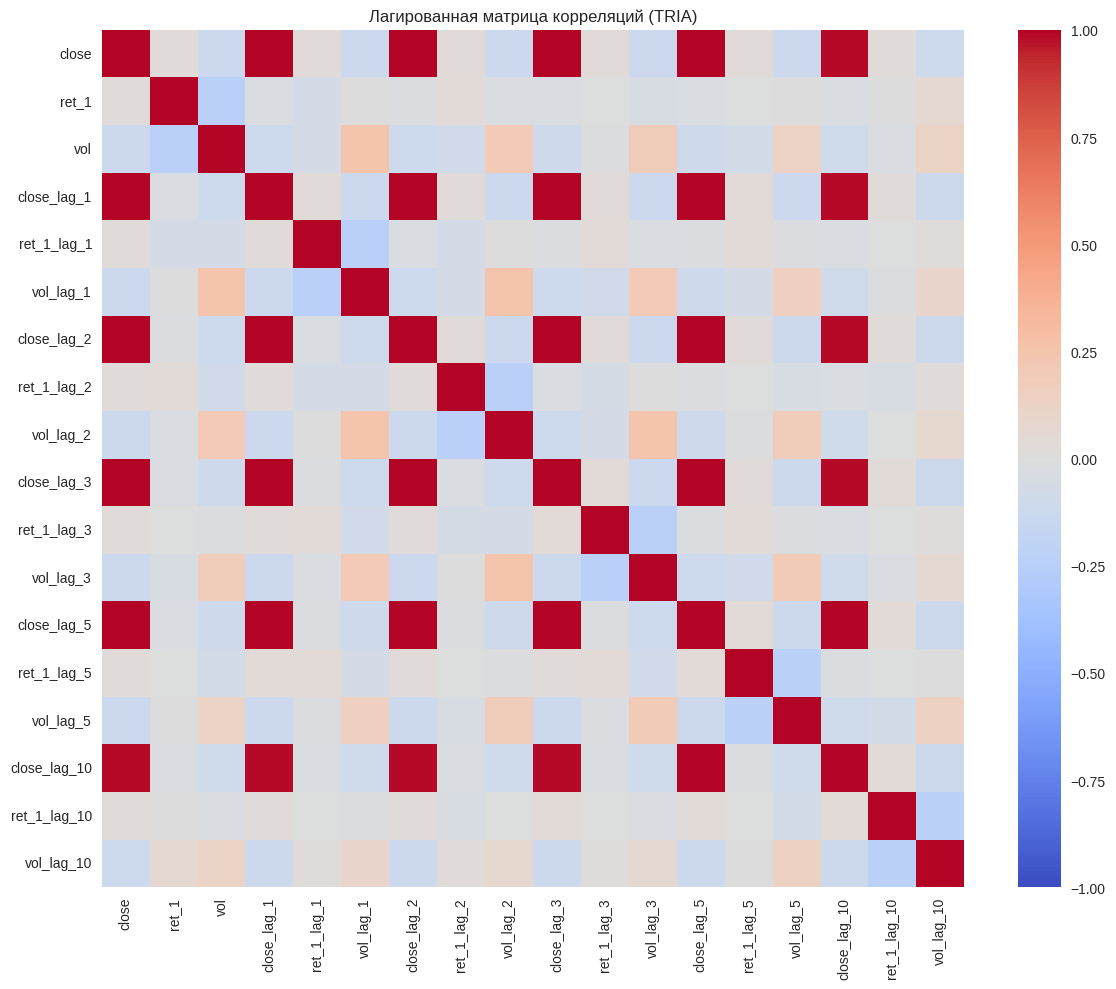

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")

df.reset_index(drop=True, inplace=True)
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

top_symbol = df["symbol"].value_counts().idxmax()
df_sym = df[df["symbol"] == top_symbol].copy()

df_sym = df_sym.reset_index(drop=True)
df_sym = df_sym.sort_values("datetime").reset_index(drop=True)

# лог-доходность по close
df_sym["ret_1"] = np.log(df_sym["close"] / df_sym["close"].shift(1))
df_sym = df_sym.dropna(subset=["ret_1"])

max_lag = 40

# ACF/PACF для цены
plt.figure(figsize=(10, 4))
plot_acf(df_sym["close"], lags=max_lag)
plt.title(f"ACF цены закрытия ({top_symbol})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df_sym["close"], lags=max_lag, method="ywm")
plt.title(f"PACF цены закрытия ({top_symbol})")
plt.tight_layout()
plt.show()

# ACF/PACF для доходностей
plt.figure(figsize=(10, 4))
plot_acf(df_sym["ret_1"], lags=max_lag)
plt.title(f"ACF доходности ({top_symbol})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df_sym["ret_1"], lags=max_lag, method="ywm")
plt.title(f"PACF доходности ({top_symbol})")
plt.tight_layout()
plt.show()

# ACF/PACF для объёма
plt.figure(figsize=(10, 4))
plot_acf(df_sym["volume"], lags=max_lag)
plt.title(f"ACF объёма ({top_symbol})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df_sym["volume"], lags=max_lag, method="ywm")
plt.title(f"PACF объёма ({top_symbol})")
plt.tight_layout()
plt.show()

# Лагированная матрица корреляций
lags = [1, 2, 3, 5, 10]

lagged_df = pd.DataFrame()
lagged_df["close"] = df_sym["close"].values
lagged_df["ret_1"] = df_sym["ret_1"].values
lagged_df["vol"] = df_sym["volume"].values

for l in lags:
    lagged_df[f"close_lag_{l}"] = df_sym["close"].shift(l).values
    lagged_df[f"ret_1_lag_{l}"] = df_sym["ret_1"].shift(l).values
    lagged_df[f"vol_lag_{l}"] = df_sym["volume"].shift(l).values

lagged_df = lagged_df.dropna()

corr = lagged_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title(f"Лагированная матрица корреляций ({top_symbol})")
plt.tight_layout()
plt.show()



## небольшие выводы